# 데이터셋 코드 테스트 - `pm_safeline`

PM 세이프라인 데이터셋 파이프라인(사고 → OSM 지점 → negative → 로드뷰 이미지 → split)을
단계별로 검증하고 **데이터 개수**를 집계한다.

- 사고 데이터셋: `datasets.accidents` (KoROAD/TAAS)
- 데이터 primitive: `datasets.primitives` (geo/negatives/streetview)
- 로드뷰 데이터셋: `datasets.roadview`

> 이미지 수집은 `mock` provider 로 검증.

In [1]:
import pandas as pd

## 1. 사고 데이터셋 - `AccidentDataset`

KoROAD 이륜차 다발지역을 표준 스키마로 로드. **사고 좌표는 자르지 않고 전부 사용**하되,
대전 밖 좌표(데이터 오류)만 제외한다.

In [2]:
from pm_safeline.datasets.accidents import AccidentDataset, CORE_COLUMNS

acc = AccidentDataset(source="koroad", download=False).to_geodataframe()
n_pos = len(acc)

print(f"사고 지점(positive): {n_pos}")
print("severity 분포:", acc['severity'].value_counts().to_dict())
acc[['accident_id', 'lat', 'lon', 'severity', 'mode']].head()

[accidents] region bbox 밖 좌표(오류 의심) 1건 제외


[accidents] 공간 중복 병합(dedup 40m): 86 -> 61 (-25)
사고 지점(positive): 61
severity 분포: {'중상': 48, '경상': 8, '사망': 5}


,accident_id,lat,lon,severity,mode
0,1,36.345429,127.445795,중상,motorcycle_frequentzone
1,2,36.347315,127.431974,사망,motorcycle_frequentzone
2,3,36.353050,127.368831,경상,motorcycle_frequentzone
3,4,36.351410,127.378420,경상,motorcycle_frequentzone
4,5,36.352113,127.376193,경상,motorcycle_frequentzone


## 2. 작업 영역 = 사고 좌표들의 실제 범위 (+여유)

In [3]:
minx, miny, maxx, maxy = acc.total_bounds
bbox = (minx - 0.01, miny - 0.01, maxx + 0.01, maxy + 0.01)   # OSM/negative 는 이 영역에서
print("작업 영역(W,S,E,N):", tuple(round(v, 3) for v in bbox))

작업 영역(W,S,E,N): (np.float64(127.25), np.float64(36.302), np.float64(127.525), np.float64(36.727))


## 3. `geo` - OSM 도로망 → 지점/스냅 (작업 영역 기준)

In [4]:
from pm_safeline.datasets.primitives import geo

edges = geo.load_drive_edges(bbox)
candidates = geo.sample_points_along_edges(edges)
acc_snapped = geo.snap_accidents_to_edges(acc, edges)
n_edges, n_cand = len(edges), len(candidates)
print(f"OSM edges: {n_edges} · 도로 후보 지점: {n_cand}")

[geo] PM 진입불가 도로 1414 edge 제외(고속도로/자동차전용도로)


OSM edges: 86770 · 도로 후보 지점: 316809


## 4. `negatives` - exposure-matched 대조지점

In [5]:
from pm_safeline.datasets.primitives import negatives

negs = negatives.sample_negatives(acc_snapped, candidates)
labeled = negatives.build_labeled_points(acc_snapped, negs)
n_neg = int((labeled.label == 0).sum())
n_pos_labeled = int((labeled.label == 1).sum())
print(f"대조 지점(negative): {n_neg}  (neg/pos = {n_neg / n_pos_labeled:.1f})")
print(f"총 라벨 지점: {len(labeled)}  (pos {n_pos_labeled} / neg {n_neg})")
labeled[['point_id', 'label', 'lat', 'lon', 'heading']].head()


대조 지점(negative): 183  (neg/pos = 3.0)
총 라벨 지점: 244  (pos 61 / neg 183)


,point_id,label,lat,lon,heading
0,acc_000000,1,36.345429,127.445795,60.7
1,acc_000001,1,36.347315,127.431974,61.1
2,acc_000002,1,36.353050,127.368831,129.5
3,acc_000003,1,36.351410,127.378420,294.4
4,acc_000004,1,36.352113,127.376193,114.9


## 5. 로드뷰 수집 파이프라인 스모크 테스트 (mock provider)

이 셀은 실제 로드뷰를 받지 않는다. `collect_images` 파이프라인(지점 → 4방향 → 파일 저장 → manifest)이
동작하는지만 확인하는 **데모**다.

- **provider = 이미지 공급원.** `naver`(실제 로드뷰), `google`, `mock` 등.
- **`mock` = 네트워크/키 없이 만드는 가짜 합성 이미지** (실제 도로 사진 아님).
- 가짜 이미지가 실제 `data/` 를 오염시키지 않도록 **임시폴더**에만 쓴다.

> 진짜 로드뷰(대전 780 / 청주 542 / 세종 48 = 1,370장)는 `naver` provider 로 별도 수집되어
> `data/manifest.csv` 에 있고, 아래 **8. 시각화의 로드뷰 샘플**이 그 실제 이미지를 읽는다.


In [6]:
import os
import tempfile
from pathlib import Path

from pm_safeline.datasets import roadview
from pm_safeline.datasets.primitives.streetview import get_provider

# 데모(mock) 이미지는 임시 폴더에만 - 실제 data/ 를 오염시키지 않음
demo_root = Path(tempfile.mkdtemp()) / "data"
os.environ['PM_SV_PROVIDER'] = "mock"   # 데모만 mock provider
subset = labeled.head(8).copy()
manifest = roadview.collect_images(subset, root=demo_root, provider=get_provider("mock"))
print(f"데모 수집(mock, 임시폴더): {len(manifest)} 이미지 / {subset.point_id.nunique()} 지점")
# 지점당 4방향 수집 → 전체 예상 이미지 수
n_img_full = len(labeled) * 4
print(f"전체 수집 시 총 이미지(지점 {len(labeled)} x 4방향): {n_img_full}")

[collect] 8/8 지점 처리


[collect] manifest 저장: C:\Users\Public\Documents\ESTsoft\CreatorTemp\tmplbg212gk\data\manifest.csv (32 이미지)
데모 수집(mock, 임시폴더): 32 이미지 / 8 지점
전체 수집 시 총 이미지(지점 244 x 4방향): 976


## 6. 학습 분할 - 지점 누수 방지 + 라벨 stratify

In [7]:
from pm_safeline.datasets.roadview import split_indices, kfold_indices

tr, va = split_indices(labeled, valid_frac=0.2, seed=42)
tp = set(labeled.iloc[tr].point_id)
vp = set(labeled.iloc[va].point_id)
print(f"train {len(tr)}지점 / valid {len(va)}지점 · 지점누수={tp & vp}")
folds = kfold_indices(labeled, n_splits=5, seed=1)
leak = any(set(labeled.iloc[a].point_id) & set(labeled.iloc[b].point_id) for a, b in folds)
print("k-fold(5) 누수:", leak, "→ False 정상")


train 195지점 / valid 49지점 · 지점누수=set()
k-fold(5) 누수: False → False 정상


## 7. 요약 - 데이터 개수

In [8]:
summary = pd.DataFrame([
    ("사고 지점 (positive)", n_pos),
    ("대조 지점 (negative)", n_neg),
    ("총 라벨 지점", len(labeled)),
    ("총 로드뷰 이미지 (수집 시)", n_img_full),
    ("OSM edges", n_edges),
    ("도로 후보 지점", n_cand),
], columns=['항목', '개수'])
print(summary.to_string(index=False))


              항목     개수
사고 지점 (positive)     61
대조 지점 (negative)    183
         총 라벨 지점    244
총 로드뷰 이미지 (수집 시)    976
       OSM edges  86770
        도로 후보 지점 316809


## 8. 시각화

- 클래스·심각도·도로 방위각 분포
- 사고/대조 지점의 지리 분포
- **실제 수집된 로드뷰 샘플**(사고 vs 대조) - `data/manifest.csv`

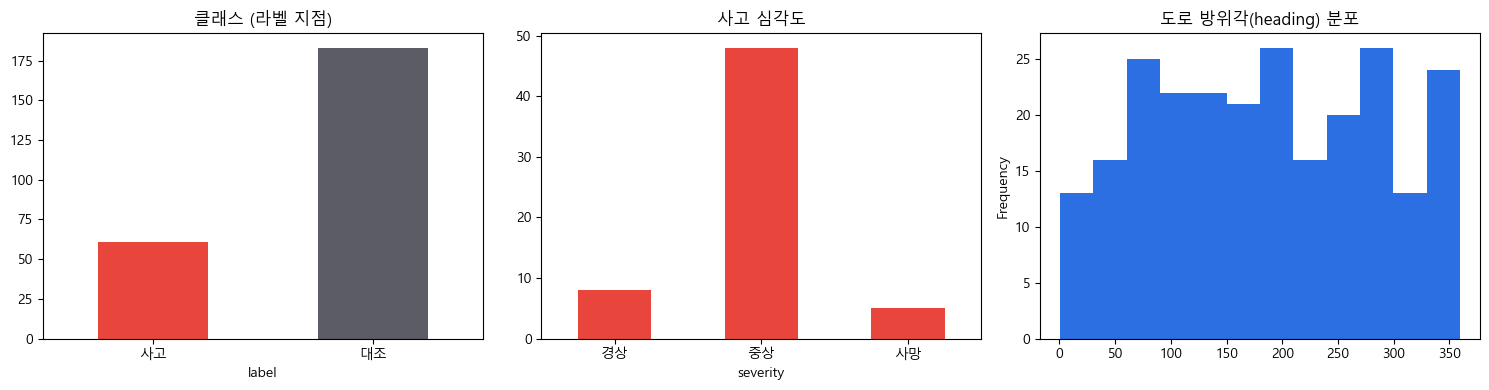

In [9]:
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['font.family'] = "Malgun Gothic"   # 한글 폰트(Windows)
matplotlib.rcParams['axes.unicode_minus'] = False
BRAND, GRAY, BLUE = "#E8453C", "#5C5C66", "#2B6FE3"

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
labeled['label'].map({1: "사고", 0: "대조"}).value_counts().reindex(["사고", "대조"]).plot.bar(
    ax=ax[0], color=[BRAND, GRAY])
ax[0].set_title("클래스 (라벨 지점)")
ax[0].tick_params(axis="x", rotation=0)
acc['severity'].value_counts().reindex(["경상", "중상", "사망"]).plot.bar(
    ax=ax[1], color=BRAND)
ax[1].set_title("사고 심각도")
ax[1].tick_params(axis="x", rotation=0)
labeled['heading'].dropna().plot.hist(bins=12, ax=ax[2], color=BLUE)
ax[2].set_title("도로 방위각(heading) 분포")
plt.tight_layout()
plt.show()


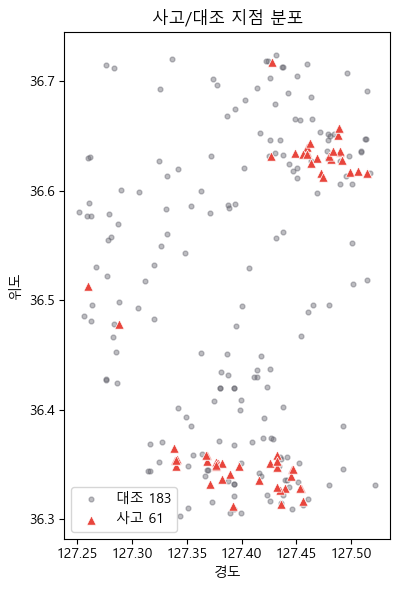

In [10]:
# 사고(빨강 ▲)/대조(회색 ·) 지점 지리 분포
fig, ax = plt.subplots(figsize=(7, 6))
neg, pos = labeled[labeled.label == 0], labeled[labeled.label == 1]
ax.scatter(neg.lon, neg.lat, s=12, c=GRAY, alpha=0.4, label=f"대조 {len(neg)}")
ax.scatter(pos.lon, pos.lat, s=45, c=BRAND, marker="^", edgecolor="white", linewidth=0.5, label=f"사고 {len(pos)}")
ax.set_xlabel("경도")
ax.set_ylabel("위도")
ax.set_title("사고/대조 지점 분포")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


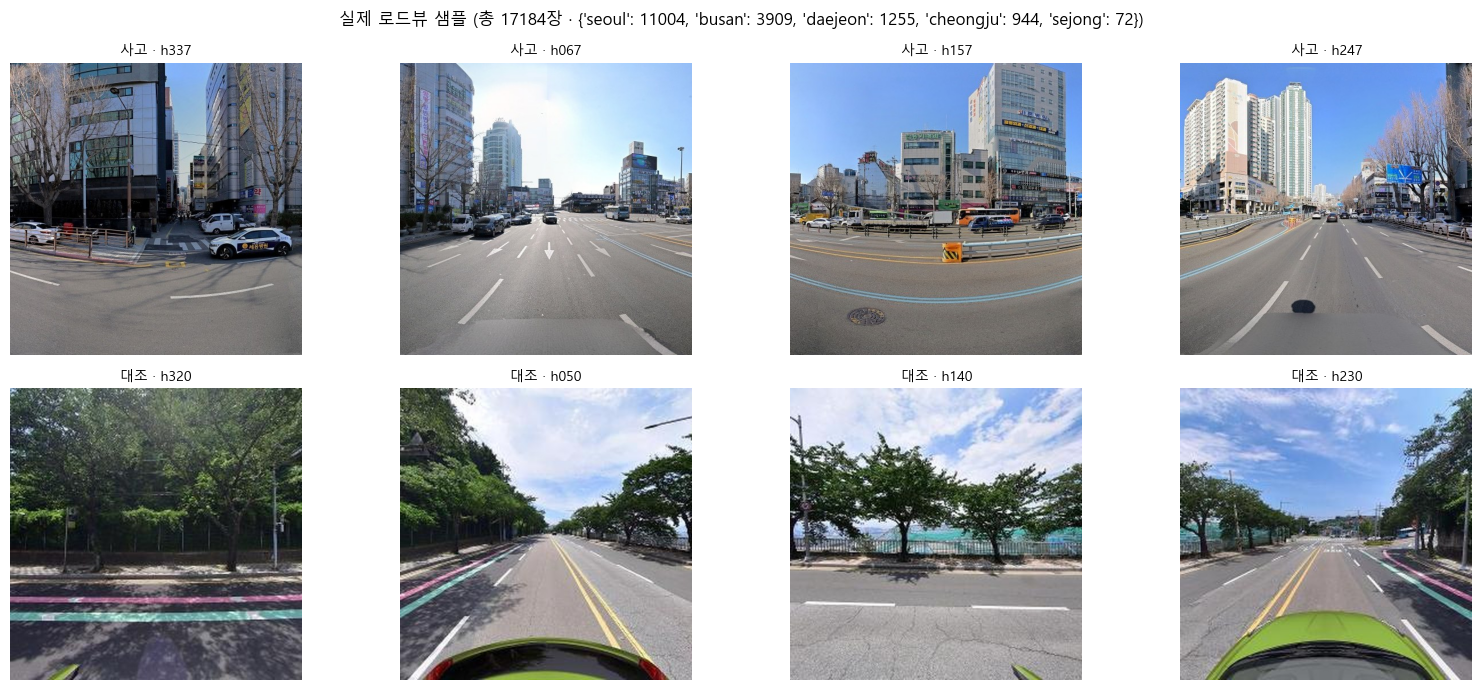

In [11]:
# 실제 수집된 로드뷰 샘플 (위: 사고 / 아래: 대조)
from PIL import Image

from pm_safeline.datasets.roadview import PMRoadviewDataset

try:
    ds = PMRoadviewDataset()   # 기본 root(=수집 데이터 위치) 사용
except FileNotFoundError:
    ds = None

if ds is None:
    print("manifest 없음 - `python -m pm_safeline collect` 로 수집 후 재실행하면 로드뷰 샘플이 표시됩니다.")
else:
    real = ds.frame
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    for r_axes, cls, title in zip(axes, ["accident", "control"], ["사고", "대조"]):
        samp = real[real['class'] == cls].head(4)
        for ax, (_, row) in zip(r_axes, samp.iterrows()):
            ip = ds.root / row['path']
            if ip.exists():
                ax.imshow(Image.open(ip))
                ax.set_title(f"{title} · h{int(row['heading']):03d}", fontsize=10)
            ax.axis("off")
    dist = real['point_id'].str.split('_').str[0].value_counts().to_dict()
    plt.suptitle(f"실제 로드뷰 샘플 (총 {len(real)}장 · {dist})", fontsize=12)
    plt.tight_layout()
    plt.show()